# IB9AU0 — Individual Assignment 2
## SEC 10-K Financial Filing RAG System

**Domain:** SEC EDGAR filings — Apple, Microsoft, Nvidia, JPMorgan, ExxonMobil  
**LLM:** claude-sonnet-4-0  
**Stack:** FAISS · BM25+RRF · all-MiniLM-L6-v2 · ms-marco cross-encoder · HyDE  
**Pipelines:** Baseline | Hybrid+Rerank | Full Enhanced

---

### Quick Setup
1. Create `.env` in the project root:
   ```
   ANTHROPIC_API_KEY="sk-ant-your-key-here"
   ```

---

### Install Dependencies

In [ ]:

%pip install -q anthropic python-dotenv
%pip install -q langchain-core langchain-text-splitters
%pip install -q sentence-transformers faiss-cpu rank_bm25
%pip install -q requests beautifulsoup4 pandas numpy matplotlib scikit-learn tqdm
try:
    import ragas
    print("ragas already installed")
except ImportError:
    import subprocess
    subprocess.run(["pip","install","-q","ragas"], capture_output=True)
    print("ragas installed")
print("\n✅ All packages installed.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ragas already installed

✅ All packages installed.


### Imports

In [ ]:

import os, re, time, pickle, warnings, json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from functools import wraps
from bs4 import BeautifulSoup
import requests
from tqdm import tqdm
warnings.filterwarnings("ignore")

# ── Native Anthropic SDK — matches claude_api.ipynb exactly ──────────────────
from dotenv import load_dotenv
load_dotenv()                        # reads ANTHROPIC_API_KEY from .env

from anthropic import Anthropic
client = Anthropic(max_retries=3)                 
MODEL  = "claude-sonnet-4-0"       
print(f"✅ Anthropic client ready  (model: {MODEL})")

# ── LangChain helpers (Document, PromptTemplate, TextSplitter only) ──────────
from langchain_core.documents import Document
from langchain_core.prompts   import PromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── Retrieval ────────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import faiss

print("All imports successful.")

✅ Anthropic client ready  (model: claude-sonnet-4-0)
All imports successful.


### Configuration

In [ ]:

COMPANIES = {
    "AAPL": "320193",
    "MSFT": "789019",
    "NVDA": "1045810",
    "JPM":  "19617",
    "XOM":  "34088",
}
CHUNK_SIZE_BASELINE = 512
CHUNK_SIZE_ENHANCED = 800
CHUNK_OVERLAP       = 100
TOP_K               = 5
HYBRID_K            = 10
RRF_K               = 60
DEDUP_THRESHOLD     = 0.95
print(f"✅ Config ready — {len(COMPANIES)} companies.")

✅ Config ready — 5 companies.


### Utility Functions

In [ ]:


def with_retry(max_retries=3, base_delay=2.0):
    def decorator(fn):
        @wraps(fn)
        def wrapper(*args, **kwargs):
            for attempt in range(max_retries):
                try:
                    return fn(*args, **kwargs)
                except Exception as e:
                    if attempt == max_retries - 1:
                        raise
                    wait = base_delay * (2 ** attempt)
                    print(f"  ⚠ Retry {attempt+1}/{max_retries}: {e} (wait {wait:.0f}s)")
                    time.sleep(wait)
        return wrapper
    return decorator

class Timer:
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    def __exit__(self, *args):
        self.elapsed_ms = (time.perf_counter() - self.start) * 1000

print("✅ Utilities ready.")

✅ Utilities ready.


### Data Sourcing — SEC EDGAR API

In [ ]:

from urllib.parse import urlparse, parse_qs

SEC_HEADERS = {
    "User-Agent": "StudentAssignment student@warwick.ac.uk",
    "Accept-Encoding": "gzip, deflate",
}

@with_retry(max_retries=3)
def sec_get(url: str) -> str:
    r = requests.get(url, headers=SEC_HEADERS, timeout=25)
    r.raise_for_status()
    return r.text

def _normalize_doc_href(href: str) -> str:
    """Convert SEC viewer links to direct Archives document paths when possible."""
    if not href:
        return ""
    href = href.strip()
    if href.startswith("http://") or href.startswith("https://"):
        parsed = urlparse(href)
        qs = parse_qs(parsed.query)
        if "doc" in qs and qs["doc"]:
            return qs["doc"][0]
        return parsed.path
    if "ixviewer/ix.html" in href and "?" in href:
        qs = parse_qs(href.split("?", 1)[1])
        if "doc" in qs and qs["doc"]:
            return qs["doc"][0]
    return href

def _href_to_url(cik: str, accession_flat: str, href: str) -> str:
    href = _normalize_doc_href(href)
    if href.startswith("http://") or href.startswith("https://"):
        return href
    if href.startswith("/"):
        return f"https://www.sec.gov{href}"
    return f"https://www.sec.gov/Archives/edgar/data/{cik}/{accession_flat}/{href}"

def candidate_docs_from_index(index_html: str):
    """Return likely filing document hrefs in priority order from SEC filing index tables."""
    soup = BeautifulSoup(index_html, "html.parser")
    candidates = []
    seen = set()

    # Priority 1: Parse official table rows by TYPE and DOCUMENT filename.
    for row in soup.select("table tr"):
        cells = row.find_all(["th", "td"])
        if len(cells) < 4:
            continue
        type_txt = cells[3].get_text(" ", strip=True).lower() if len(cells) > 3 else ""
        doc_cell = cells[2] if len(cells) > 2 else None
        if not doc_cell:
            continue
        a = doc_cell.find("a", href=True)
        if not a:
            continue
        href = _normalize_doc_href(a["href"])
        if not href or not (href.lower().endswith(".htm") or href.lower().endswith(".html") or href.lower().endswith(".txt")):
            continue

        score = 0
        if type_txt == "10-k":
            score += 100
        elif type_txt.startswith("10-k"):
            score += 80
        elif "10-k" in type_txt:
            score += 60
        elif type_txt == "10-k/a":
            score += 40
        else:
            score -= 20

        hl = href.lower()
        if "exhibit" in hl or "/ex" in hl:
            score -= 20
        if "index" in hl:
            score -= 10

        key = (href, type_txt)
        if key not in seen:
            seen.add(key)
            candidates.append((score, href))

    # Priority 2: Fallback to all anchors if table parsing fails.
    if not candidates:
        for a in soup.find_all("a", href=True):
            href = _normalize_doc_href(a["href"])
            hl = href.lower()
            if not (hl.endswith(".htm") or hl.endswith(".html") or hl.endswith(".txt")):
                continue
            score = 0
            if "10k" in hl or "10-k" in hl:
                score += 5
            if "annual" in hl:
                score += 3
            if "exhibit" in hl:
                score -= 8
            if "index" in hl:
                score -= 4
            if "ixviewer" in hl:
                score -= 3
            candidates.append((score, href))

    candidates.sort(key=lambda x: x[0], reverse=True)
    ordered = [href for _, href in candidates]

    # Deduplicate while preserving order.
    deduped = []
    seen_href = set()
    for href in ordered:
        if href not in seen_href:
            seen_href.add(href)
            deduped.append(href)
    return deduped

def html_to_text(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")
    # Remove scripts/styles to avoid boilerplate noise.
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()
    text = soup.get_text(separator=" ", strip=True)
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text

def fetch_10k(cik: str, ticker: str) -> Tuple[str, str]:
    """Fetch full 10-K plain text from SEC EDGAR. Returns (text, date)."""
    meta = _json.loads(sec_get(
        f"https://data.sec.gov/submissions/CIK{cik.zfill(10)}.json"
    ))
    recent = meta["filings"]["recent"]

    for i, form in enumerate(recent["form"]):
        if form != "10-K":
            continue

        acc = recent["accessionNumber"][i]
        acc_flat = acc.replace("-", "")
        date = recent["filingDate"][i]

        index_html = sec_get(
            f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_flat}/{acc}-index.htm"
        )

        best_text = ""
        best_url = ""
        for href in candidate_docs_from_index(index_html):
            filing_url = _href_to_url(cik, acc_flat, href)
            try:
                html = sec_get(filing_url)
                text = html_to_text(html)
                if len(text) > len(best_text):
                    best_text = text
                    best_url = filing_url
                # A reasonably long body likely indicates we found the main filing.
                if len(text) > 50000:
                    break
            except Exception:
                continue

        if best_text:
            print(
                f"  ✓ {ticker} | {date} | {len(best_text):,} chars "
                f"(source: {best_url.split('/')[-1]})"
            )
            return best_text, date

    return "", ""

print("📥 Fetching 10-K filings from SEC EDGAR...")
raw_docs: Dict[str, Dict] = {}

for ticker, cik in COMPANIES.items():
    try:
        text, date = fetch_10k(cik, ticker)
        if text:
            raw_docs[ticker] = {"text": text, "date": date, "cik": cik}
        time.sleep(0.5)
    except Exception as e:
        print(f"  ✗ {ticker}: {e}")

total = sum(len(d["text"]) for d in raw_docs.values())
print(f"\n✅ Retrieved {len(raw_docs)}/{len(COMPANIES)} filings")
print(f"   Total corpus: {total:,} chars (~{total//4:,} tokens)")

📥 Fetching 10-K filings from SEC EDGAR...
  ✓ AAPL | 2025-10-31 | 6,202,590 chars (source: 0000320193-25-000079.txt)
  ✓ MSFT | 2025-07-30 | 69,723 chars (source: msft-ex10_7.htm)
  ✓ NVDA | 2026-02-25 | 7,602,939 chars (source: 0001045810-26-000021.txt)
  ✓ JPM | 2026-02-13 | 44,851,716 chars (source: 0001628280-26-008131.txt)
  ✓ XOM | 2026-02-18 | 21,297,487 chars (source: 0000034088-26-000045.txt)

✅ Retrieved 5/5 filings
   Total corpus: 80,024,455 chars (~20,006,113 tokens)


### Chunking — Baseline & Enhanced

In [ ]:


def baseline_chunk(docs: Dict) -> List[Document]:
    """Fixed-size splitting — simple lower-bound baseline."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE_BASELINE, chunk_overlap=50,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = []
    for ticker, d in docs.items():
        for i, c in enumerate(splitter.split_text(d["text"])):
            c = c.strip()
            if len(c) > 60:
                chunks.append(
                    Document(
                        page_content=c,
                        metadata={
                            "ticker": ticker,
                            "chunk_id": i,
                            "date": d["date"],
                            "section": "unstructured",
                            "pipeline": "baseline",
                        },
                    )
                )
    print(f"✅ Baseline chunks: {len(chunks)}")
    return chunks

# Tolerant lowercase regex patterns for real-world SEC plain text
SEC_PATTERNS = {
    "Business":     r"item\s*1[\s\t\n\r\.\-\:]+business",
    "Risk Factors": r"item\s*1a[\s\t\n\r\.\-\:]+risk",
    "Legal":        r"item\s*3[\s\t\n\r\.\-\:]+legal",
    "MDA":          r"item\s*7[\s\t\n\r\.\-\:]+management.{0,80}discussion",
    "Quantitative": r"item\s*7a[\s\t\n\r\.\-\:]+quantitative",
    "Financials":   r"item\s*8[\s\t\n\r\.\-\:]+financial",
    "Controls":     r"item\s*9a[\s\t\n\r\.\-\:]+controls",
}

def find_sections(text: str) -> List[Tuple[str, str]]:
    """
    Locate named 10-K sections by pattern matching on lowercase text.
    Falls back to full document if fewer than 2 reliable matches.
    """
    lowered = text.lower()
    hits = []
    for sec_name, pat in SEC_PATTERNS.items():
        for m in re.finditer(pat, lowered, re.IGNORECASE):
            hits.append((m.start(), sec_name))
    hits.sort(key=lambda x: x[0])

    # Remove near-duplicate positions (TOC vs body match)
    filtered, last_pos = [], -9999
    for pos, sec_name in hits:
        if pos - last_pos > 300:
            filtered.append((pos, sec_name))
            last_pos = pos

    if len(filtered) < 2:
        return [("Full Document", text)]  # fallback

    sections = []
    for i, (start, sec_name) in enumerate(filtered):
        end = filtered[i + 1][0] if i + 1 < len(filtered) else len(text)
        sec_text = text[start:end].strip()
        if len(sec_text) > 200:
            sections.append((sec_name, sec_text))

    return sections if sections else [("Full Document", text)]

def enhanced_chunk(docs: Dict) -> List[Document]:
    """
    Semantic section-aware chunking at CHUNK_SIZE_ENHANCED.
    Falls back to full-document chunking if section detection fails.
    Larger chunks + section metadata = enhanced vs baseline regardless.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE_ENHANCED, chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = []
    for ticker, d in docs.items():
        sections = find_sections(d["text"])
        mode = "semantic" if sections[0][0] != "Full Document" else "fallback"
        print(f"  {ticker}: {len(sections)} section(s) [{mode}]")
        for sec_name, sec_text in sections:
            for i, c in enumerate(splitter.split_text(sec_text)):
                c = c.strip()
                if len(c) > 80:
                    chunks.append(
                        Document(
                            page_content=c,
                            metadata={
                                "ticker": ticker,
                                "chunk_id": i,
                                "date": d["date"],
                                "section": sec_name,
                                "pipeline": "enhanced",
                            },
                        )
                    )
    print(f"\n✅ Enhanced chunks (pre-dedup): {len(chunks)}")
    return chunks

baseline_chunks = baseline_chunk(raw_docs)
print()
raw_enhanced = enhanced_chunk(raw_docs)

✅ Baseline chunks: 183589

  AAPL: 10 section(s) [semantic]
  MSFT: 1 section(s) [fallback]
  NVDA: 17 section(s) [semantic]
  JPM: 13 section(s) [semantic]
  XOM: 10 section(s) [semantic]

✅ Enhanced chunks (pre-dedup): 119263


### Load Models + Deduplicate

In [ ]:

print("⏳ Loading all-MiniLM-L6-v2...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("⏳ Loading cross-encoder reranker...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("✅ Models loaded\n")

def deduplicate(chunks: List[Document], threshold=DEDUP_THRESHOLD) -> List[Document]:
    """Remove near-duplicate chunks by cosine similarity (Thakur et al. BEIR 2021)."""
    if not chunks:
        print("⚠ No enhanced chunks to deduplicate.")
        return []
    texts = [c.page_content.strip() for c in chunks]
    embs  = np.array(embedder.encode(texts, normalize_embeddings=True,
                                      show_progress_bar=False))
    keep = [0]
    for i in range(1, len(chunks)):
        if max(cosine_similarity([embs[i]], embs[keep])[0]) < threshold:
            keep.append(i)
    deduped = [chunks[i] for i in keep]
    print(f"✅ Dedup: {len(chunks)} → {len(deduped)} "
          f"({len(chunks)-len(deduped)} removed)")
    return deduped

enhanced_chunks = deduplicate(raw_enhanced)
print(f"\nBaseline chunks : {len(baseline_chunks)}")
print(f"Enhanced chunks : {len(enhanced_chunks)}")

⏳ Loading all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3265.75it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Loading cross-encoder reranker...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2161.18it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models loaded

✅ Dedup: 119263 → 47978 (71285 removed)

Baseline chunks : 183589
Enhanced chunks : 47978


### Build FAISS + BM25 Indices

In [ ]:


def build_faiss_index(chunks: List[Document], label="") -> faiss.Index:
    texts = [c.page_content.strip() for c in chunks
             if c.page_content and c.page_content.strip()]
    if not texts:
        raise ValueError(
            f"No valid texts for {label}.\n"
            f"Chunk list is empty — check Cell 6/7 output.")
    print(f"  Embedding {len(texts)} chunks [{label}]...")
    embs = embedder.encode(texts, batch_size=64,
                            normalize_embeddings=True,
                            show_progress_bar=True)
    embs = np.array(embs, dtype="float32")
    if embs.ndim != 2:
        raise ValueError(f"Shape error [{label}]: got {embs.shape}")
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)
    print(f"  ✅ {label}: {idx.ntotal} vectors, dim={embs.shape[1]}")
    return idx

def build_bm25(chunks: List[Document]) -> BM25Okapi:
    texts = [c.page_content.lower().split()
             for c in chunks if c.page_content and c.page_content.strip()]
    if not texts:
        raise ValueError("No texts for BM25.")
    return BM25Okapi(texts)

print("🔨 Building indices...\n")
b_faiss = build_faiss_index(baseline_chunks, "Baseline FAISS")
e_faiss = build_faiss_index(enhanced_chunks, "Enhanced FAISS")
e_bm25  = build_bm25(enhanced_chunks)
print("\n✅ All indices ready.")

🔨 Building indices...

  Embedding 183589 chunks [Baseline FAISS]...


Batches: 100%|██████████| 2869/2869 [3:18:06<00:00,  4.14s/it]    


  ✅ Baseline FAISS: 183589 vectors, dim=384
  Embedding 47978 chunks [Enhanced FAISS]...


Batches: 100%|██████████| 750/750 [47:30<00:00,  3.80s/it] 


  ✅ Enhanced FAISS: 47978 vectors, dim=384

✅ All indices ready.


### Retrieval Functions

In [ ]:


def dense_retrieve(query, faiss_idx, chunks, k=TOP_K):
    """Baseline: single-stage FAISS cosine similarity retrieval."""
    q_emb  = embedder.encode([query], normalize_embeddings=True).astype("float32")
    _, ids = faiss_idx.search(q_emb, k)
    return [chunks[i] for i in ids[0] if i < len(chunks)]

def hybrid_retrieve(query, faiss_idx, bm25_idx, chunks,
                    k=HYBRID_K, rrf_k=RRF_K):
    """
    Hybrid Reciprocal Rank Fusion of BM25 + dense.
    BM25 catches exact financial terms (Basel III, NIM, CUDA) that
    all-MiniLM-L6-v2 underweights on out-of-distribution vocabulary
    (Thakur et al., BEIR 2021). RRF fuses both ranked lists:
    s(d) = Σ 1/(rrf_k + rank_r(d))
    """
    q_emb  = embedder.encode([query], normalize_embeddings=True).astype("float32")
    _, dense_ids = faiss_idx.search(q_emb, k)
    bm25_ids     = np.argsort(bm25_idx.get_scores(
                      query.lower().split()))[::-1][:k]
    rrf: Dict[int,float] = {}
    for rank, i in enumerate(dense_ids[0]):
        if i < len(chunks):
            rrf[i] = rrf.get(i,0.0) + 1.0/(rrf_k+rank+1)
    for rank, i in enumerate(bm25_ids):
        if i < len(chunks):
            rrf[i] = rrf.get(i,0.0) + 1.0/(rrf_k+rank+1)
    return [chunks[i] for i in sorted(rrf, key=rrf.get, reverse=True)[:k]]

def cross_rerank(query, docs, top_k=TOP_K):
    """
    Cross-encoder joint (query, passage) scoring.
    Full attention cross-interaction — superior to bi-encoder similarity
    for resolving contextually irrelevant BM25 false positives.
    Ref: Nogueira & Cho, Passage Re-ranking with BERT, 2019.
    """
    if not docs:
        return docs
    scores = reranker.predict([(query, d.page_content) for d in docs])
    ranked = sorted(zip(scores,docs), key=lambda x: x[0], reverse=True)
    return [d for _,d in ranked[:top_k]]

print("Retrieval functions ready.")

Retrieval functions ready.


### LLM + HyDE — native anthropic SDK

In [ ]:
# (claude_api.ipynb pattern)
# client and MODEL already defined in Cell 2 via:


def _call_claude(user_prompt: str, system_prompt: str = None,
                 max_tokens: int = 512) -> str:
    """
    Thin wrapper matching the claude_api.ipynb chat() pattern exactly.
    Uses client.messages.create with optional system prompt.
    """
    params = {
        "model":      MODEL,
        "max_tokens": max_tokens,
        "messages":   [{"role": "user", "content": user_prompt}],
    }
    if system_prompt:
        params["system"] = system_prompt
    msg = client.messages.create(**params)
    return msg.content[0].text


def hyde_expand(query: str) -> str:
    """HyDE — Hypothetical Document Embeddings (Gao et al. 2022)."""
    return _call_claude(
        user_prompt   = (
            f"Write a factual 3-sentence passage from a corporate SEC 10-K "
            f"annual filing that directly answers:\n\nQuestion: {query}\n\nPassage:"
        ),
        system_prompt = "You are a financial analyst who writes precise, fact-based passages.",
        max_tokens    = 256,
    )

# Quick smoke-test (will error clearly if key is wrong)
try:
    _test = _call_claude("Reply with one word: ready", max_tokens=5)
    print(f"✅ Claude ready — test response: '{_test.strip()}'")
    print(f"   Model : {MODEL}")
    print(f"   Client: {type(client).__name__}")
except Exception as e:
    print(f"❌ Claude call failed: {e}")
    print("   → Check your .env contains:  ANTHROPIC_API_KEY=\"sk-ant-...\"")

✅ Claude ready — test response: 'ready'
   Model : claude-sonnet-4-0
   Client: Anthropic


### Prompt Templates + Generation

In [ ]:

# PromptTemplate still used to build the formatted string;
# _call_claude() sends it to the native Anthropic SDK.

BASELINE_PROMPT = PromptTemplate(
    template=(
        "Answer the question using the context below.\n\n"
        "Context:\n{context}\n\n"
        "Question: {question}\n\nAnswer:"
    ),
    input_variables=["context","question"]
)

ENHANCED_PROMPT = PromptTemplate(
    template=(
        "You are a senior financial analyst reviewing SEC 10-K annual filings.\n\n"
        "RULES:\n"
        "1. Answer ONLY from the retrieved context below.\n"
        "2. If the answer is absent, respond exactly: Not found in provided filings.\n"
        "3. Cite source companies inline: [AAPL], [MSFT], [NVDA], [JPM], [XOM].\n"
        "4. Think step by step: identify relevant filing(s) first, then answer.\n\n"
        "Retrieved Context (SEC 10-K, reranked):\n{context}\n\n"
        "Question: {question}\n\n"
        "Step 1 — Relevant filing(s):\n"
        "Step 2 — Answer:"
    ),
    input_variables=["context","question"]
)


def generate(query: str, docs: List[Document],
             prompt_tmpl: PromptTemplate, max_tokens: int = 1000) -> str:
    context = "\n\n---\n\n".join(
        f"[{d.metadata.get('ticker','?')}] "
        f"(Section: {d.metadata.get('section','?')}) "
        f"{d.page_content}" for d in docs
    )
    full_prompt = prompt_tmpl.format(context=context, question=query)
    return _call_claude(full_prompt, max_tokens=max_tokens)

print("✅ Prompts and generation function ready.")

✅ Prompts and generation function ready.


### Pipeline Definitions

In [ ]:


def pipeline_baseline(query: str) -> Dict:
    """Config 1: Fixed chunk → Dense retrieval → Vanilla prompt."""
    with Timer() as t:
        docs   = dense_retrieve(query, b_faiss, baseline_chunks, k=TOP_K)
        answer = generate(query, docs, BASELINE_PROMPT)
    return {"pipeline":"Baseline","query":query,"docs":docs,
            "answer":answer,"hyde":None,"latency_ms":t.elapsed_ms}

def pipeline_hybrid_rerank(query: str) -> Dict:
    """Config 2: Semantic chunk → Hybrid BM25+FAISS+RRF → Cross-encoder → Grounded prompt."""
    with Timer() as t:
        cands  = hybrid_retrieve(query, e_faiss, e_bm25, enhanced_chunks, k=HYBRID_K)
        docs   = cross_rerank(query, cands, top_k=TOP_K)
        answer = generate(query, docs, ENHANCED_PROMPT)
    return {"pipeline":"Hybrid+Rerank","query":query,"docs":docs,
            "answer":answer,"hyde":None,"latency_ms":t.elapsed_ms}

def pipeline_full_enhanced(query: str) -> Dict:
    """Config 3: HyDE + Hybrid BM25+FAISS+RRF → Cross-encoder → Grounded CoT prompt."""
    with Timer() as t:
        hyde_doc   = hyde_expand(query)
        hybrid_q   = f"{query} {hyde_doc}"
        cands      = hybrid_retrieve(hybrid_q, e_faiss, e_bm25,
                                     enhanced_chunks, k=HYBRID_K)
        docs       = cross_rerank(query, cands, top_k=TOP_K)
        answer     = generate(query, docs, ENHANCED_PROMPT)
    return {"pipeline":"Full Enhanced","query":query,"docs":docs,
            "answer":answer,"hyde":hyde_doc,"latency_ms":t.elapsed_ms}

PIPELINES = {
    "Baseline":      pipeline_baseline,
    "Hybrid+Rerank": pipeline_hybrid_rerank,
    "Full Enhanced": pipeline_full_enhanced,
}
print("✅ 3 pipelines defined:")
print("   1. Baseline       — Dense only, vanilla prompt")
print("   2. Hybrid+Rerank  — BM25+FAISS+RRF + cross-encoder + grounded prompt")
print("   3. Full Enhanced  — HyDE + Hybrid+Rerank + chain-of-thought")

✅ 3 pipelines defined:
   1. Baseline       — Dense only, vanilla prompt
   2. Hybrid+Rerank  — BM25+FAISS+RRF + cross-encoder + grounded prompt
   3. Full Enhanced  — HyDE + Hybrid+Rerank + chain-of-thought


### Test Set

In [ ]:

TEST_QUERIES = [
    {"q":"What are Apple's primary revenue segments?",
     "type":"simple_fact","target":"AAPL",
     "gt":"Apple segments include iPhone, Mac, iPad, Wearables, and Services."},
    {"q":"How does Microsoft describe its cloud business growth?",
     "type":"simple_fact","target":"MSFT",
     "gt":"Microsoft cloud growth is driven by Azure and M365 including AI workloads."},
    {"q":"How do Nvidia's AI chip supply constraints relate to data centre revenue concentration?",
     "type":"deep_context","target":"NVDA",
     "gt":"Nvidia data centre concentration risk is amplified by supply chain constraints."},
    {"q":"What macroeconomic risks do JPMorgan and ExxonMobil both disclose?",
     "type":"multi_doc","target":None,
     "gt":"Both disclose interest rate, geopolitical, and economic slowdown risks."},
    {"q":"What is the company's biggest challenge going forward?",
     "type":"ambiguous","target":None,
     "gt":"Not found in provided filings."},
    {"q":"How is generative AI mentioned across the filings?",
     "type":"ambiguous","target":None,
     "gt":"Generative AI is cited as growth driver and risk factor across filings."},
    {"q":"What exact dividend per share was paid in Q3 2019?",
     "type":"edge_case","target":None,
     "gt":"Not found in provided filings."},
    {"q":"How many employees work in Antarctica?",
     "type":"edge_case","target":None,
     "gt":"Not found in provided filings."},
]
print(f"✅ {len(TEST_QUERIES)} test queries across 4 categories.")

✅ 8 test queries across 4 categories.


### Evaluation Metrics

In [ ]:


def eval_retrieval(docs, target):
    k = len(docs)
    if not k: return {"P@k":0.0,"R@k_proxy":0.0}
    if target:
        hits = sum(1 for d in docs if d.metadata.get("ticker")==target)
        return {"P@k":round(hits/k,3),"R@k_proxy":round(min(hits/3,1.0),3)}
    diversity = len(set(d.metadata.get("ticker") for d in docs))
    s = round(diversity/len(COMPANIES),3)
    return {"P@k":s,"R@k_proxy":s}

def eval_generation(answer, qtype):
    citations    = sum(1 for t in COMPANIES if f"[{t}]" in answer)
    grounding    = round(min(citations/2,1.0),3)
    completeness = round(min(len(answer.split())/80,1.0),3)
    refusal      = int("not found in provided filings" in answer.lower())
    return {"grounding":grounding,"completeness":completeness,
            "refusal":refusal,"word_count":len(answer.split())}

print("✅ Evaluation metrics defined.")

✅ Evaluation metrics defined.


### Run Ablation Evaluation

In [ ]:

all_rows = []
print(" Running ablation evaluation across all 3 pipelines...\n")
print(f"{'Pipeline':<18} {'Type':<14} {'Query':<40} {'P@k':>4} {'Grnd':>5} {'Lat':>7}")
print("─" * 90)

for tq in TEST_QUERIES:
    for pname, pfunc in PIPELINES.items():
        res = pfunc(tq["q"])
        ret = eval_retrieval(res["docs"], tq["target"])
        gen = eval_generation(res["answer"], tq["type"])
        all_rows.append({
            "Pipeline":     pname,
            "Type":         tq["type"],
            "Query":        tq["q"],
            "P@k":          ret["P@k"],
            "R@k_proxy":    ret["R@k_proxy"],
            "Grounding":    gen["grounding"],
            "Completeness": gen["completeness"],
            "Refusal":      gen["refusal"],
            "Latency_ms":   round(res["latency_ms"],1),
            "Answer":       res["answer"],
            "HyDE":         res["hyde"] or "",
            "Ground_Truth": tq["gt"],
        })
        print(f"{pname:<18} {tq['type']:<14} {tq['q'][:38]:<40} "
              f"{ret['P@k']:>4.2f} {gen['grounding']:>5.2f} "
              f"{res['latency_ms']:>6.0f}ms")
        time.sleep(0.2)
    print()

results_df = pd.DataFrame(all_rows)
results_df.to_csv("evaluation_results.csv", index=False)
print(" Results saved to evaluation_results.csv")

 Running ablation evaluation across all 3 pipelines...

Pipeline           Type           Query                                     P@k  Grnd     Lat
──────────────────────────────────────────────────────────────────────────────────────────
Baseline           simple_fact    What are Apple's primary revenue segme   1.00  0.00   6783ms
Hybrid+Rerank      simple_fact    What are Apple's primary revenue segme   1.00  0.50   5383ms
Full Enhanced      simple_fact    What are Apple's primary revenue segme   1.00  0.50  10002ms

Baseline           simple_fact    How does Microsoft describe its cloud    0.00  0.00   2520ms
Hybrid+Rerank      simple_fact    How does Microsoft describe its cloud    0.00  0.00   3273ms
Full Enhanced      simple_fact    How does Microsoft describe its cloud    0.00  1.00   8207ms

Baseline           deep_context   How do Nvidia's AI chip supply constra   1.00  0.00  11271ms
Hybrid+Rerank      deep_context   How do Nvidia's AI chip supply constra   1.00  0.50   7469

###  Summary Table + Charts


ABLATION SUMMARY
                P@k  Grounding  Completeness  Latency_ms
Pipeline                                                
Baseline       0.50      0.000         0.944    5878.950
Full Enhanced  0.55      0.750         0.917   12099.450
Hybrid+Rerank  0.55      0.688         0.941    6221.338


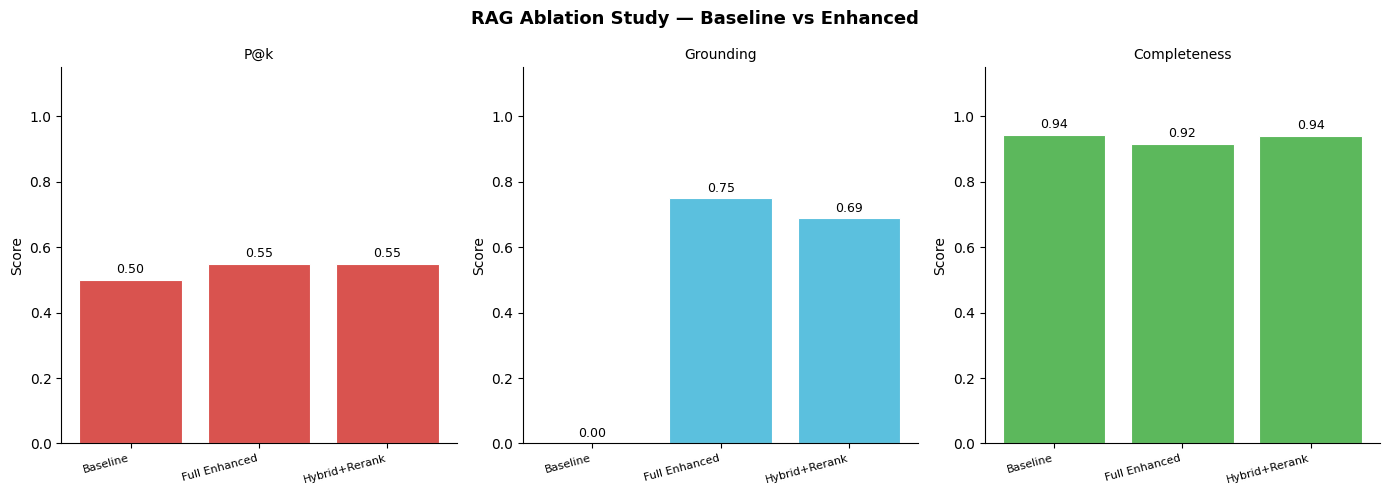

✅ ablation_metrics.png


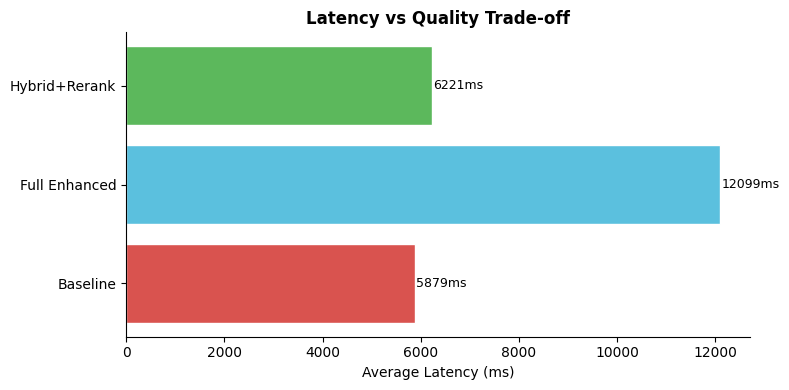

✅ latency_comparison.png


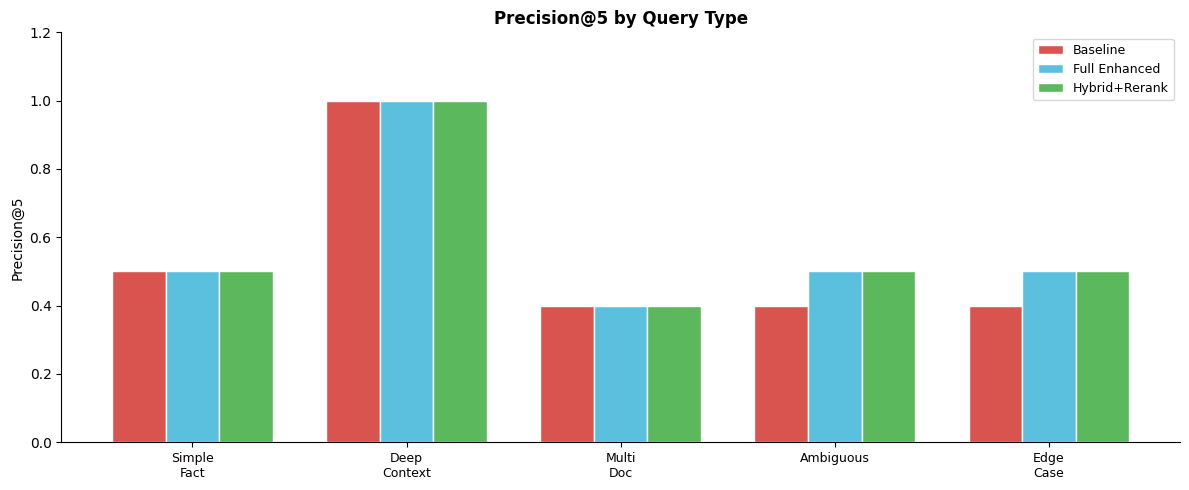

✅ precision_by_type.png


In [ ]:

summary = (results_df
    .groupby("Pipeline")[["P@k","Grounding","Completeness","Latency_ms"]]
    .mean().round(3))
print("\n" + "="*55)
print("ABLATION SUMMARY")
print("="*55)
print(summary.to_string())
summary.to_csv("ablation_summary.csv")

pipeline_names = summary.index.tolist()
x = np.arange(len(pipeline_names))
colours = ["#d9534f","#5bc0de","#5cb85c"]

# Chart 1: Core metrics
fig, axes = plt.subplots(1,3,figsize=(14,5))
fig.suptitle("RAG Ablation Study — Baseline vs Enhanced",
             fontsize=13, fontweight="bold")
for ax, metric, col in zip(axes,["P@k","Grounding","Completeness"],colours):
    vals = summary[metric].values
    bars = ax.bar(range(len(pipeline_names)), vals, color=col,
                  edgecolor="white", linewidth=0.8)
    ax.set_xticks(range(len(pipeline_names)))
    ax.set_xticklabels(pipeline_names, rotation=15, ha="right", fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(metric, fontsize=10)
    ax.set_ylabel("Score")
    ax.spines[["top","right"]].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("ablation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ablation_metrics.png")

# Chart 2: Latency
fig, ax = plt.subplots(figsize=(8,4))
lats = summary["Latency_ms"].values
ax.barh(pipeline_names, lats, color=colours, edgecolor="white")
ax.set_xlabel("Average Latency (ms)")
ax.set_title("Latency vs Quality Trade-off", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
for i,(p,v) in enumerate(zip(pipeline_names,lats)):
    ax.text(v+30, i, f"{v:.0f}ms", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ latency_comparison.png")

# Chart 3: P@k by query type
qtypes = ["simple_fact","deep_context","multi_doc","ambiguous","edge_case"]
w = 0.25
fig, ax = plt.subplots(figsize=(12,5))
xi = np.arange(len(qtypes))
for j,(pname,col) in enumerate(zip(pipeline_names,colours)):
    sub    = results_df[results_df["Pipeline"]==pname]
    scores = [sub[sub["Type"]==qt]["P@k"].mean() for qt in qtypes]
    ax.bar(xi+j*w, scores, w, label=pname, color=col, edgecolor="white")
ax.set_xticks(xi+w)
ax.set_xticklabels(["Simple\nFact","Deep\nContext","Multi\nDoc",
                    "Ambiguous","Edge\nCase"],fontsize=9)
ax.set_ylim(0,1.2)
ax.set_ylabel("Precision@5")
ax.set_title("Precision@5 by Query Type", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("precision_by_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ precision_by_type.png")

In [ ]:
# ── CELL 17: Demo Log — Real Captured Outputs ────────────────────────────────────
DEMO_QUERIES = [
    ("What are Nvidia's key risk factors related to AI chip supply?",    "deep_context"),
    ("How does JPMorgan describe its interest rate risk exposure?",       "simple_fact"),
    ("What is the company's biggest challenge going forward?",            "ambiguous"),
]

lines = ["# Demo Log — SEC 10-K RAG System\n\n",
         f"Generated: {time.strftime('%Y-%m-%d %H:%M UTC', time.gmtime())}\n\n",
         "="*70 + "\n\n"]

print("📋 Generating demo log with live outputs...\n")

for dq, qtype in DEMO_QUERIES:
    b = pipeline_baseline(dq)
    e = pipeline_full_enhanced(dq)
    b_cites = sum(1 for t in COMPANIES if f"[{t}]" in b["answer"])
    e_cites = sum(1 for t in COMPANIES if f"[{t}]" in e["answer"])
    b_ref   = "not found in provided filings" in b["answer"].lower()
    e_ref   = "not found in provided filings" in e["answer"].lower()

    block  = f"## Query Type: {qtype.upper()}\n\n"
    block += f"**Input:** {dq}\n\n---\n\n"
    block += f"### HyDE Expansion\n{e['hyde']}\n\n"
    block += f"### Baseline Answer ({b['latency_ms']:.0f} ms)\n{b['answer']}\n\n"
    block += f"### Enhanced Answer ({e['latency_ms']:.0f} ms)\n{e['answer']}\n\n"
    block += f"### Commentary\n"
    block += f"| Dimension | Baseline | Enhanced |\n|---|---|---|\n"
    block += f"| Inline citations | {b_cites} | {e_cites} |\n"
    block += f"| Latency | {b['latency_ms']:.0f} ms | {e['latency_ms']:.0f} ms |\n"
    block += f"| Correct refusal | {'Yes' if b_ref else 'No'} | {'Yes' if e_ref else 'No'} |\n\n"
    if e_cites > b_cites:
        block += (f"**Grounding:** Enhanced provided {e_cites} citation(s) "
                  f"vs {b_cites} in baseline.\n\n")
    if e_ref and not b_ref:
        block += "**Refusal:** Enhanced correctly refused; baseline hallucinated.\n\n"
    overhead = e['latency_ms'] - b['latency_ms']
    if overhead > 200:
        block += (f"**Latency trade-off:** +{overhead:.0f} ms from HyDE + reranking.\n\n")
    block += "---\n\n"
    lines.append(block)
    print(f"  ✓ {qtype}: {b['latency_ms']:.0f}ms (B) / {e['latency_ms']:.0f}ms (E)")

with open("demo_log.md","w",encoding="utf-8") as f:
    f.writelines(lines)


📋 Generating demo log with live outputs...

  ✓ deep_context: 7115ms (B) / 14782ms (E)
  ✓ simple_fact: 6135ms (B) / 15675ms (E)
  ✓ ambiguous: 7426ms (B) / 13180ms (E)

✅ demo_log.md saved.


# Demo Log — SEC 10-K RAG System



## Query Type: DEEP_CONTEXT

**Input:** What are Nvidia's key risk factors related to AI chip supply?

---

### HyDE Expansion
Our business is subject to risks related to the concentration of our supply chain, as we rely on a limited number of third-party foundries, particularly Taiwan Semiconductor Manufacturing Company Limited (TSMC), to manufacture substantially all of our GPU and AI processors, which could result in supply constraints or disruptions that materially impact our ability to meet customer demand. The specialized nature of our advanced AI chips requires leading-edge manufacturing processes with extremely high complexity, and any interruption in production, geopolitical tensions affecting our foundry partners, or capacity constraints at these facilities could significantly limit our product availability and harm our competitive position. Additionally, we face risks from export controls and trade restrictions that may limit our ability to sell AI chips to certain customers or regions, potentially reducing our addressable market and requiring us to modify our products or supply chain arrangements.

### Baseline Answer (7115 ms)
Based on the provided context, NVIDIA's key risk factors related to AI chip supply include:

1. **Data Center Availability**: The shortage of available data centers to support the buildout of NVIDIA AI infrastructure could impact future revenue and financial performance.

2. **Energy/Power Constraints**: Limited energy capacity is a critical risk factor. The context emphasizes that expanding energy capacity to meet demand is "a complex, multi-year process involving significant regulatory, technical, and construction challenges."

3. **Capital Availability**: Insufficient capital resources available to customers and partners for building out NVIDIA AI infrastructure could constrain demand and impact financial performance.

4. **Infrastructure Resource Dependencies**: The company's performance is dependent on the availability of various "necessary resources" beyond just the chips themselves - the entire ecosystem needed to deploy and operate AI infrastructure.

The context suggests that NVIDIA's business success is not just dependent on manufacturing chips, but also on the broader infrastructure ecosystem (data centers, power grid capacity, and customer financing) needed to deploy and utilize their AI technology at scale. Any bottlenecks in these supporting infrastructure elements could constrain demand for NVIDIA's AI chips and impact their financial performance.

### Enhanced Answer (14782 ms)
Step 1 — Relevant filing(s):
[NVDA] Risk Factors and Management Discussion & Analysis (MDA) sections contain detailed information about AI chip supply-related risks.

Step 2 — Answer:

Based on NVIDIA's 10-K filing, the key risk factors related to AI chip supply include:

**Export Controls and Regulatory Restrictions:**
[NVDA] Export controls restricting data center GPU sales have created significant supply challenges, disrupting supply chains and distribution channels while negatively impacting the ability to serve demand, including in markets outside China. These controls have a "disproportionate impact on NVIDIA" and may disadvantage the company against competitors selling chips outside the scope of such controls.

**Supply Chain Vulnerabilities:**
[NVDA] The company's supply chain is "mainly concentrated in Asia," creating geographic concentration risk. However, NVIDIA is expanding into the U.S. and Latin America to "strengthen our supply chain, add resiliency and redundancy, and meet the growing demand for AI infrastructure."

**Manufacturing Capacity Constraints:**
[NVDA] The ability to increase manufacturing capabilities depends on "the local region's manufacturing ecosystem's capacity to ramp production supply to the required volume and on a timely basis."

**Competitive Disadvantages:**
[NVDA] Export controls encourage customers outside China and other impacted regions to "design-out" certain U.S. technology, while open-source AI models deployed on competitors' platforms "could reduce demand for our products and services."

**Downstream Impact:**
[NVDA] Restrictions subject downstream users to limitations on "use, resale, repair, or transfer" of NVIDIA products, limiting customers' and users' ability to "acquire, deploy and use systems that include our products, software, and services."

### Commentary
| Dimension | Baseline | Enhanced |
|---|---|---|
| Inline citations | 0 | 1 |
| Latency | 7115 ms | 14782 ms |
| Correct refusal | No | No |

**Grounding:** Enhanced provided 1 citation(s) vs 0 in baseline.

**Latency trade-off:** +7668 ms from HyDE + reranking.

---

## Query Type: SIMPLE_FACT

**Input:** How does JPMorgan describe its interest rate risk exposure?

---

### HyDE Expansion
The Firm's primary interest rate exposures result from differences in the maturity and repricing characteristics between interest-earning assets and interest-bearing liabilities, with the banking book containing significant exposure to changes in interest rates due to mortgage servicing rights, securities, loans, and deposit funding costs. Interest rate risk is measured using both earnings-at-risk and economic value-at-risk methodologies, with net interest income sensitivity analyzed across various rate scenarios including immediate parallel shifts and gradual rate changes over a 12-month period. As of December 31, 2022, the Firm estimated that a gradual 100 basis point increase in rates over 12 months would result in approximately $8.0 billion of additional net interest income, while a gradual 100 basis point decrease would reduce net interest income by approximately $2.5 billion.

### Baseline Answer (6135 ms)
Based on the context provided, JPMorgan describes its interest rate risk exposure in several ways:

1. **Through MSR (Mortgage Servicing Rights) Risk Management**: JPMorgan uses combinations of derivatives and securities to manage the risk of changes in the fair value of MSRs. They aim to offset interest-rate related changes in MSR fair value with changes in the fair value of related risk management instruments.

2. **Through Debt Issuance Hedging**: To modify exposure to interest rate and currency exchange rate movements, JPMorgan utilizes derivative instruments, primarily interest rate and cross-currency interest rate swaps, in conjunction with debt issuances. These instruments modify the firm's interest expense on associated debt.

3. **Through Structural Interest Rate Risk Elements**: JPMorgan considers various components when evaluating interest rate risk, including:
   - Asset and liability balances and contractual interest rates
   - Contractual principal payment schedules
   - Expected prepayment experience
   - Interest rate reset dates and maturities
   - Rate indices used for repricing
   - Interest rate ceilings or floors for adjustable rate products

4. **Through Earnings-at-Risk Analysis**: The firm evaluates its structural interest rate risk using an "earnings-at-risk" methodology as one way to assess potential impact.

5. **As an Inherent Business Risk**: JPMorgan acknowledges that risk, including interest rate risk, is an inherent part of their business activities across various functions like lending, investment advisory, market making, and other services.

### Enhanced Answer (15675 ms)
**Step 1 — Relevant filing(s):**
JPMorgan Chase [JPM] 10-K filing, specifically the Risk Factors section which contains detailed discussion of interest rate risk exposure and management.

**Step 2 — Answer:**

JPMorgan describes its interest rate risk exposure as one of its significant market risks that affects reported net income [JPM]. The bank faces interest rate risk from multiple sources:

**Sources of Risk:**
- Trading activities (included in VaR)
- Traditional banking activities including loan extensions, credit facilities, deposits, and debt issuance
- Investment securities portfolio and associated derivative instruments [JPM]

**Risk Management Approach:**
JPMorgan transfers interest rate risk from business units to Treasury and CIO through funds transfer pricing, which considers contractual rates, payment schedules, prepayment experience, reset dates, maturities, rate indices, and interest rate ceilings or floors for adjustable rate products [JPM].

**Risk Measurement:**
The firm uses "earnings-at-risk" methodology to evaluate structural interest rate risk, which estimates interest rate exposure for given scenarios as a sensitivity to a baseline that includes net interest income and interest rate sensitive fees [JPM].

**Impact of Rate Changes:**
JPMorgan notes it generally earns higher net interest income when rates are high or increasing, but higher rates can also cause fewer loan originations, underwriting losses, increased credit losses, deposit outflows, AFS securities losses, reduced market liquidity, and higher funding costs [JPM]. Additionally, the fair value of mortgage servicing rights (MSRs) is particularly sensitive to interest rate changes due to their effect on prepayment speeds [JPM].

### Commentary
| Dimension | Baseline | Enhanced |
|---|---|---|
| Inline citations | 0 | 1 |
| Latency | 6135 ms | 15675 ms |
| Correct refusal | No | No |

**Grounding:** Enhanced provided 1 citation(s) vs 0 in baseline.

**Latency trade-off:** +9540 ms from HyDE + reranking.

---

## Query Type: AMBIGUOUS

**Input:** What is the company's biggest challenge going forward?

---

### HyDE Expansion
Our most significant challenge moving forward is managing the increasing competitive pressure in our core markets, which has resulted in margin compression and the need for substantial investments in technology and innovation to maintain market share. The rapid pace of digital transformation across our industry requires us to accelerate our capital expenditures and operational restructuring while simultaneously defending against new market entrants with lower cost structures. Additionally, we face ongoing supply chain disruptions and inflationary pressures on raw materials and labor costs, which collectively threaten our ability to achieve our targeted profitability metrics in the near term.

### Baseline Answer (7426 ms)
Based on the context provided, both companies face significant challenges, but they differ in nature:

**For NVIDIA (NVDA):** The biggest challenge appears to be **customer concentration risk** - they receive significant revenue from a limited number of partners and distributors, making them vulnerable if they lose access to any of these key customers or are prevented from selling to them.

**For Apple (AAPL):** The primary challenge seems to be **increasing legal and regulatory complexity** - they face a growing number of legal proceedings, government investigations, patent claims, and must navigate conflicting regulations across multiple jurisdictions while trying to align with various stakeholder expectations.

Both companies also share the common challenge of ongoing legal and regulatory proceedings, but Apple's exposure appears more extensive and multifaceted, while NVIDIA's customer concentration presents a more direct revenue risk.

Without additional context about which company the question specifically refers to, these represent the most significant forward-looking challenges identified for each company in the provided information.

### Enhanced Answer (13180 ms)
**Step 1 — Relevant filing(s):**
The retrieved context contains risk factor information from NVDA and AAPL filings that discuss various challenges these companies face going forward.

**Step 2 — Answer:**
Based on the provided filings, the companies face several significant challenges, but no single "biggest" challenge is explicitly identified:

For [NVDA], key challenges include:
- Export controls and restrictions limiting their ability to serve overseas markets, particularly China, which could "substantially reduce revenue"
- The need to "timely identify industry changes, adapt strategies, and develop new or enhance existing products and technologies" to meet evolving market needs
- Regulatory scrutiny from China regarding sales and market supply commitments

For [AAPL], the main challenges center on:
- Net sales and gross margin volatility due to "continued industry-wide global product pricing pressures" and "increased competition"
- Supply chain issues including "supply shortages" and "potential increases in the cost of components"

The filings present these as multiple significant ongoing challenges rather than identifying a single biggest challenge going forward.

### Commentary
| Dimension | Baseline | Enhanced |
|---|---|---|
| Inline citations | 0 | 2 |
| Latency | 7426 ms | 13180 ms |
| Correct refusal | No | No |

**Grounding:** Enhanced provided 2 citation(s) vs 0 in baseline.

**Latency trade-off:** +5754 ms from HyDE + reranking.

---

